In [1]:
import cfe

cfe.logger.setLevel("DEBUG")

cfe.settings.backend = "cfe_docker"

[10/22/2025 05:05:31] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: 'ref'                                                                                                                                       
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                              

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe', 'id'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [3]:
parameters = {"prune_milestone": False}
method = cfe.method.FateMethod(method_name="stavia")
method.infer_trajectory(fadata, parameters)

                      DEBUG    CFEDockerBackend __init__                                                                                                                                                
[10/22/2025 05:05:32] DEBUG    Docker image(huangzhaoyang/stavia:0.0.1) loaded, entry point is 'None'                                                                                                   
                      DEBUG    Loaded function 'stavia': <function stavia at 0x75986403c820>                                                                                                            
                      INFO     method backend loaded: CFE Docker Backend: stavia in docker image 'huangzhaoyang/stavia:0.0.1'                                                                           
                      DEBUG    extract prior information automatically: {'start_cell', 'cluster'}                                                                                                   

                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251022_170532__stavia-cfe_docker__XNba5uhvmp, basis:X_umap.                                                          
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (210, 500) for '20251022_170532__stavia-cfe_docker__XNba5uhvmp', finished!                                                                    

<Axes: title={'center': 'stavia-cfe_docker(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

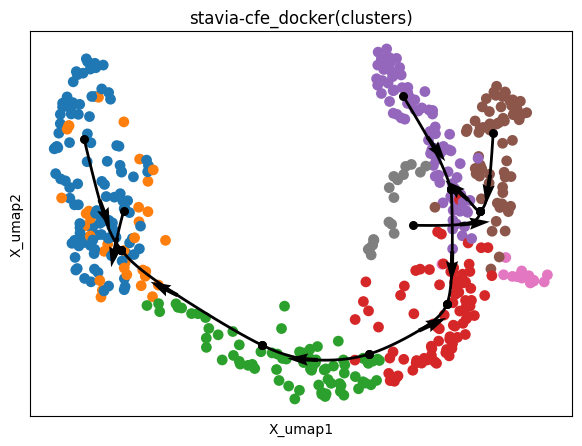

In [4]:
# fix for isolated milestones and cells.
cfe.plot.plot_trajectory(fadata, color="clusters")